In [104]:
#### DATA 543 Testing Code ####
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import scipy.stats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [127]:
###Import Data from the Github Repo and Clean + Format
base_path = 'Local Data/'
start_date = '2010-01-09'
end_date = '2025-12-31'

df_localtemps = pd.read_csv(base_path +'local_weather.csv') #daily temp observations, precipitation at Shasta Dam
df_localtemps = df_localtemps.drop(columns=['STATION', 'NAME', 'DAPR', 'MDPR', 'SNOW', 'SNWD'])
df_localtemps['DATE'] = pd.to_datetime(df_localtemps['DATE'], format='mixed')
df_localtemps.columns = ['Date', 'Precipitation', 'Max Temp (F)', 'Min Temp (F)', 'Observed Temp (F)']
df_localtemps = df_localtemps.set_index('Date').sort_index()

df_hdd_cdd = pd.read_csv(base_path + 'hdd_cdd.csv') #monthly hdd and cdd
df_hdd_cdd['Date'] = pd.to_datetime(df_hdd_cdd['Date'], format='%Y%m')
df_hdd_cdd = df_hdd_cdd.set_index('Date').sort_index()
df_hdd_cdd = df_hdd_cdd.resample('D').ffill() #fill out monthly data to days

df_ONI = pd.read_csv(base_path + 'Monthly Oceanic Nino Index (ONI) - Long.csv') #monthly
df_ONI['Date'] = pd.to_datetime(dict(year=df_ONI['Year'], month=df_ONI['MonthNum'], day=1)) #dataframe ends 12-01-2025 not 12-31 so need to manually add the extra days so that there are no NaN entries to the model
df_ONI = df_ONI.set_index('Date').sort_index()
df_ONI = df_ONI.drop(columns = ['Year', 'MonthTxt', 'MonthNum'])
last = df_ONI.index.max()
next_month = last + pd.offsets.MonthBegin(1)
df_ONI.loc[next_month] = df_ONI.loc[last]
df_ONI = df_ONI.resample('D').ffill()
df_ONI.columns = ['ONI']

df_pricedata = pd.read_csv(base_path + 'price_data.csv')
df_pricedata.columns = ['Date', 'PX_LAST', 'Lag [t-1]', 'Lag [t-7]', 'Rolling Average [7d]', 'Rolling Average [30d]', 'NatGas Lag [t-1]', 'NatGas Lag [t-7]', 'NatGas Rolling [7d]', 'NatGas Rolling [30d]', 'NatGas Rolling 2 [30d]'] #temporary we can name these whatever evenutally
df_pricedata['Date'] = pd.to_datetime(df_pricedata['Date'], format='%m/%d/%Y')
df_pricedata = df_pricedata.set_index('Date').sort_index()
df_pricedata = df_pricedata.drop(columns = ['NatGas Rolling 2 [30d]'])

dfs = [df_hdd_cdd, df_ONI, df_localtemps, df_pricedata] #add new dataframes here

#double check no duplicates, aligned indexes, etc. to prepare for splice and join
cleaned = []
for df in dfs:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    cleaned.append(df)
dfs = cleaned
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata = dfs

    
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata = dfs #add back in any new dataframes

monthly_df_list = [df_hdd_cdd, df_ONI]
daily_df_list = [df_pricedata, df_localtemps]

df_monthly = pd.concat(monthly_df_list, axis=1, join='outer') #join into seperate sets for later
df_daily = pd.concat(daily_df_list, axis=1, join='outer')

n_vars_monthly = df_monthly.shape[1] #variable so we don't have to mess with stuff in the model as we add stuff
n_vars_daily = df_daily.shape[1]

combined_df = pd.concat([df_monthly, df_daily], axis = 1, join = 'outer') #one total dataframe

df_daily NaNs:
 PX_LAST                  0
Lag [t-1]                0
Lag [t-7]                0
Rolling Average [7d]     0
Rolling Average [30d]    0
NatGas Lag [t-1]         0
NatGas Lag [t-7]         0
NatGas Rolling [7d]      0
NatGas Rolling [30d]     0
Precipitation            0
Max Temp (F)             0
Min Temp (F)             0
Observed Temp (F)        0
dtype: int64
df_monthly NaNs:
 HDD (F)    0
CDD (F)    0
ONI        0
dtype: int64
df_daily index freq: D
df_monthly index freq: D
X_daily any NaN: False
X_month any NaN: False
y any NaN: False
X_daily any Inf: False
X_month any Inf: False
y any Inf: False
X_daily: (5814, 13, 15)
X_month: (5814, 3)
y: (5814, 7)
Epoch 01 | Train Loss: 403.4607 | Val Loss: 1202.7841
Epoch 02 | Train Loss: 270.2217 | Val Loss: 1229.2932
Epoch 03 | Train Loss: 262.0935 | Val Loss: 1045.5587
Epoch 04 | Train Loss: 255.4830 | Val Loss: 958.1765
Epoch 05 | Train Loss: 240.7297 | Val Loss: 999.4044
Epoch 06 | Train Loss: 232.2434 | Val Loss: 789.6055

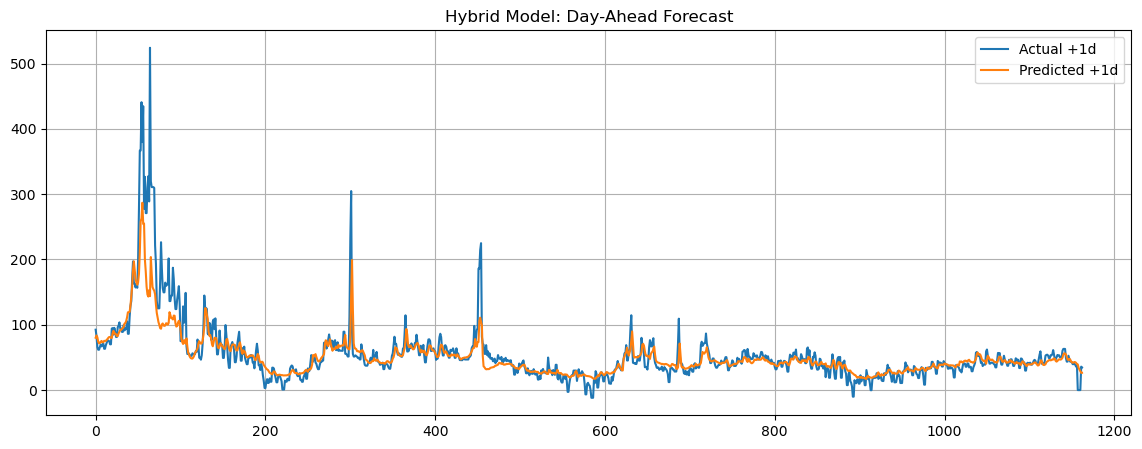

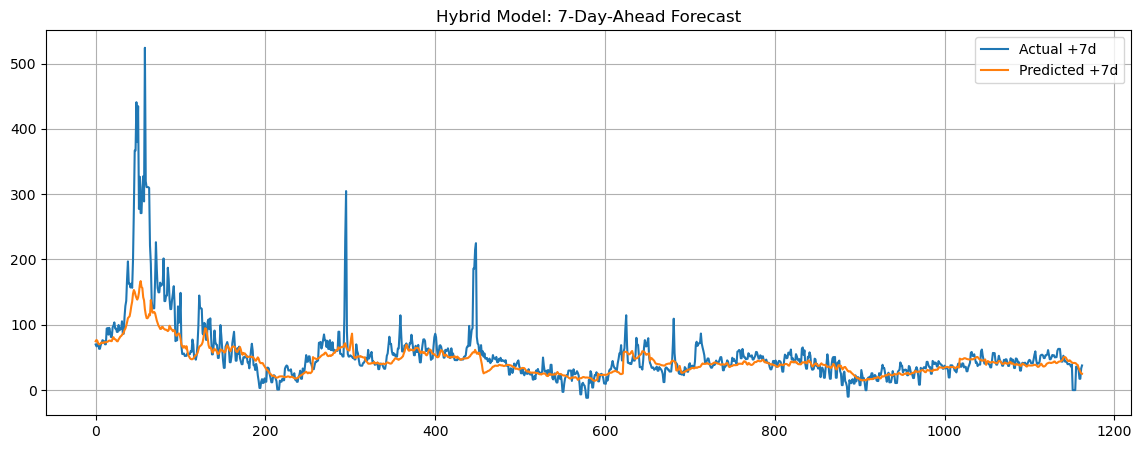

In [ ]:
############################################################################

#print("df_daily NaNs:\n", df_daily.isna().sum())  ####DATA CLEANING CHECKS
#print("df_monthly NaNs:\n", df_monthly.isna().sum())
#print("df_daily index freq:", df_daily.index.inferred_freq)
#print("df_monthly index freq:", df_monthly.index.inferred_freq)

############################################################################
#Create sliding windows with daily + monthly features
#  X_daily: (samples, n_vars_daily, window)
#  X_month: (samples, n_vars_monthly)
#  y:       (samples, horizon)
############################################################################

def create_hybrid_windows(daily_df, monthly_daily_df, window=15, horizon=7):
    X_daily, X_month, y = [], [], []
    daily_vals = daily_df.values
    monthly_vals = monthly_daily_df.values
    n = len(daily_df)

    for i in range(n - window - horizon):
        X_daily.append(daily_vals[i:i+window].T)  # (vars, window)
        X_month.append(monthly_vals[i+window-1])  # (3,) # Monthly features taken at the last day of the window
        y.append(daily_vals[i+window:i+window+horizon, 0]) # Target: next horizon days of first daily variable (PX_LAST!!!)
    
    print("X_daily any NaN:", np.isnan(X_daily).any())
    print("X_month any NaN:", np.isnan(X_month).any())
    print("y any NaN:", np.isnan(y).any())

    print("X_daily any Inf:", np.isinf(X_daily).any())
    print("X_month any Inf:", np.isinf(X_month).any())
    print("y any Inf:", np.isinf(y).any())

    return np.array(X_daily), np.array(X_month), np.array(y)

window = 15
horizon = 7

X_daily, X_month, y = create_hybrid_windows(
    df_daily,
    df_monthly,
    window=window,
    horizon=horizon
)

print("X_daily:", X_daily.shape)
print("X_month:", X_month.shape)  
print("y:", y.shape)               

######################################################################
# Dataset + DataLoader
######################################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]

split = int(0.8 * len(X_daily))
train_ds = HybridClimateDataset(X_daily[:split], X_month[:split], y[:split])
val_ds   = HybridClimateDataset(X_daily[split:], X_month[split:], y[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

##########################################################################
# Month/Day Hybid model
##########################################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        # Daily CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2), #padding prevents data loss on the edges of the set
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Monthly MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion + output
        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        daily_latent = self.cnn(x_daily).squeeze(-1)  # (batch, 64)
        month_latent = self.mlp(x_month)              # (batch, 32)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)

model = HybridCNN(
    in_channels_daily=n_vars_daily,
    monthly_features=n_vars_monthly,
    horizon=horizon
)

################################################################
# Training Loop
################################################################

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb_daily, xb_month)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = model(xb_daily, xb_month)
            val_loss += criterion(pred, yb).item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

###############################################################
# Predictions (Output)
###############################################################

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        preds.append(model(xb_daily, xb_month).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

###############################################################
# Model Eval: day-ahead and 7-day-ahead
###############################################################

# Day-ahead (horizon 1)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,0], label="Actual +1d")
plt.plot(preds[:,0], label="Predicted +1d")
plt.title("Hybrid Model: Day-Ahead Forecast")
plt.legend()
plt.grid(True)
plt.show()

# 7-day-ahead (horizon 7)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,6], label="Actual +7d")
plt.plot(preds[:,6], label="Predicted +7d")
plt.title("Hybrid Model: 7-Day-Ahead Forecast")
plt.legend()
plt.grid(True)
plt.show()

X_daily any NaN: False
X_month any NaN: False
y any NaN: False
X_daily any Inf: False
X_month any Inf: False
y any Inf: False
X_daily: (5819, 13, 10)
X_month: (5819, 3)
y: (5819, 7)
Epoch 01 | Train Loss: 5.3947 | Val Loss: 6.4533
Epoch 02 | Train Loss: 2.7964 | Val Loss: 5.7619
Epoch 03 | Train Loss: 2.7653 | Val Loss: 5.8443
Epoch 04 | Train Loss: 2.6952 | Val Loss: 5.5508
Epoch 05 | Train Loss: 2.6748 | Val Loss: 5.6795
Epoch 06 | Train Loss: 2.6354 | Val Loss: 5.0628
Epoch 07 | Train Loss: 2.5559 | Val Loss: 4.9880
Epoch 08 | Train Loss: 2.5610 | Val Loss: 4.8694
Epoch 09 | Train Loss: 2.5726 | Val Loss: 5.7841
Epoch 10 | Train Loss: 2.5149 | Val Loss: 5.4595
Epoch 11 | Train Loss: 2.5301 | Val Loss: 4.4460
Epoch 12 | Train Loss: 2.4811 | Val Loss: 4.9946
Epoch 13 | Train Loss: 2.4774 | Val Loss: 5.4160
Epoch 14 | Train Loss: 2.4828 | Val Loss: 4.8686
Epoch 15 | Train Loss: 2.4276 | Val Loss: 4.9448
Epoch 16 | Train Loss: 2.4298 | Val Loss: 5.2462
Epoch 17 | Train Loss: 2.4268 | Va

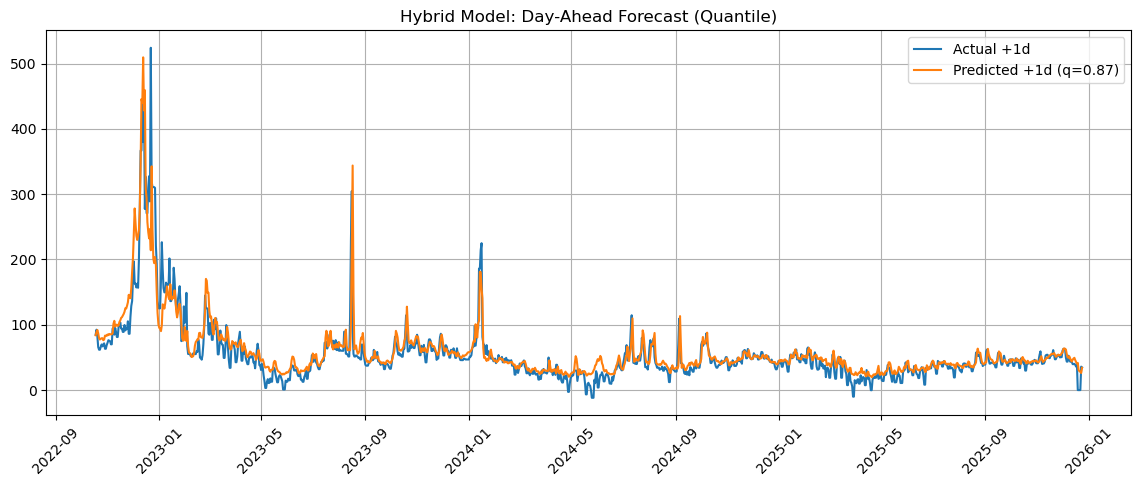

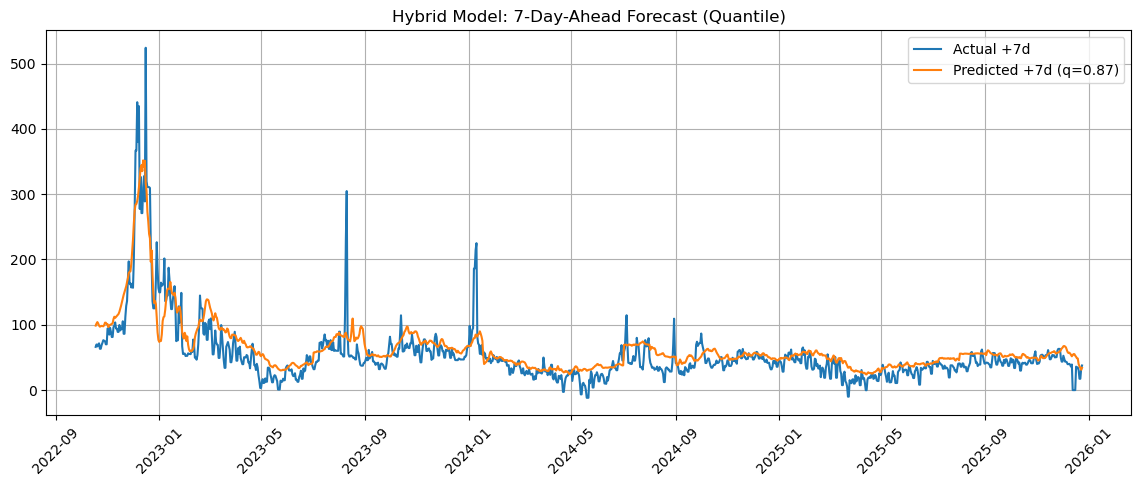

In [ ]:
############################################################################
# Try Same Process with Quantiles instead of RMSE
############################################################################

def create_hybrid_windows(daily_df, monthly_daily_df, window=10, horizon=7):
    X_daily, X_month, y = [], [], []
    daily_vals = daily_df.values
    monthly_vals = monthly_daily_df.values
    n = len(daily_df)

    for i in range(n - window - horizon):
        X_daily.append(daily_vals[i:i+window].T)  # (vars, window)
        X_month.append(monthly_vals[i+window-1])  # Monthly features taken at the last day of the window
        y.append(daily_vals[i+window:i+window+horizon, 0]) # Target: next horizon days of first daily variable

    # NaN checking
    X_daily_arr = np.array(X_daily)
    X_month_arr = np.array(X_month)
    y_arr       = np.array(y)

    print("X_daily any NaN:", np.isnan(X_daily_arr).any())
    print("X_month any NaN:", np.isnan(X_month_arr).any())
    print("y any NaN:", np.isnan(y_arr).any())

    print("X_daily any Inf:", np.isinf(X_daily_arr).any())
    print("X_month any Inf:", np.isinf(X_month_arr).any())
    print("y any Inf:", np.isinf(y_arr).any())

    return X_daily_arr, X_month_arr, y_arr

window = 10
horizon = 7

X_daily, X_month, y = create_hybrid_windows(
    df_daily,
    df_monthly,
    window=window,
    horizon=horizon
)

print("X_daily:", X_daily.shape)   
print("X_month:", X_month.shape)   
print("y:", y.shape)               

n_vars_daily   = X_daily.shape[1]
n_vars_monthly = X_month.shape[1]

######################################################################
# DataSet Class
######################################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y       = torch.tensor(y,       dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]

split = int(0.8 * len(X_daily))
train_ds = HybridClimateDataset(X_daily[:split], X_month[:split], y[:split])
val_ds   = HybridClimateDataset(X_daily[split:], X_month[split:], y[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

#######################################################################
# Hybrid model
#######################################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        # Daily CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Monthly MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion + output
        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        # x_daily: (batch, vars, window)
        daily_latent = self.cnn(x_daily).squeeze(-1)  # (batch, 64)
        month_latent = self.mlp(x_month)              # (batch, 32)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)

model = HybridCNN(
    in_channels_daily=n_vars_daily,
    monthly_features=n_vars_monthly,
    horizon=horizon
)

###################################################################
# Quantiles
###################################################################
def quantile_loss(q, y, f):
    e = y - f
    return torch.max(q * e, (q - 1) * e).mean()

q = 0.87  # Goal is to improve matching with peaks, volatility
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 25
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb_daily, xb_month)
        loss = quantile_loss(q, yb, pred)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = model(xb_daily, xb_month)
            val_loss += quantile_loss(q, yb, pred).item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

###################################################################
# Predictions on validation set
###################################################################

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        out = model(xb_daily, xb_month)
        preds.append(out.detach().numpy())
        actuals.append(yb.detach().numpy())

preds   = np.vstack(preds)
actuals = np.vstack(actuals)

#####################################################################
# Results
#####################################################################

val_dates = df_daily.index[window + split : window + split + len(actuals)] #fix x-axis dates

plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,0], label="Actual +1d")
plt.plot(val_dates, preds[:,0],   label=f"Predicted +1d (q={q})")
plt.title("Hybrid Model: Day-Ahead Forecast (Quantile)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,6], label="Actual +7d")
plt.plot(val_dates, preds[:,6],   label=f"Predicted +7d (q={q})")
plt.title("Hybrid Model: 7-Day-Ahead Forecast (Quantile)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()



In [129]:
df_daily

,PX_LAST,Lag [t-1],Lag [t-7],Rolling Average [7d],Rolling Average [30d],NatGas Lag [t-1],NatGas Lag [t-7],NatGas Rolling [7d],NatGas Rolling [30d],Precipitation,Max Temp (F),Min Temp (F),Observed Temp (F)
Date,,,,,,,,,,,,,
2010-01-09,48.46,55.16,45.14,51.217143,50.457500,5.92,5.92,6.248,6.248000,0.16,47.0,41.0,45.897837
2010-01-10,48.37,48.46,50.90,50.855714,50.225556,5.92,5.92,6.248,6.248000,0.05,54.0,45.0,46.086377
2010-01-11,53.43,48.37,50.21,51.315714,50.546000,5.85,5.95,6.182,6.193333,0.00,56.0,42.0,43.103282
2010-01-12,52.36,53.43,51.60,51.424286,50.710909,5.90,6.11,6.100,6.144286,0.95,50.0,43.0,45.168006
2010-01-13,49.04,52.36,49.69,51.331429,50.571667,6.07,6.03,6.042,6.113750,2.57,52.0,45.0,47.043405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,17.35,30.33,0.00,21.834286,38.462000,3.00,2.24,2.410,3.486923,1.90,56.0,35.0,35.000000
2025-12-28,17.35,17.35,0.00,24.312857,37.372000,3.00,2.24,2.410,3.486923,0.00,50.0,35.0,44.909204
2025-12-29,33.23,17.35,0.00,29.060000,36.798000,3.00,2.24,2.300,3.486923,0.00,56.0,43.0,46.998529
